In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 2. Load Dataset
file_path = "/Users/manaschakraborty/Downloads/Loan-Approval-Prediction.csv"
df = pd.read_csv(file_path)

In [2]:
# 3. Initial Overview
print(df.info())
print(df.head())
print(df['Loan_Status'].value_counts())  # Check class balance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0 

In [5]:
# 4. Handle Missing Values
# Categorical columns → fill with mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns → fill with median
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [6]:
# 5. Convert Dependents '3+' to 3 and numeric type
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)


In [7]:
# 6. Feature Engineering
# Total Income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Log transform to reduce skew
df['LoanAmount_log'] = np.log(df['LoanAmount'])
df['TotalIncome_log'] = np.log(df['TotalIncome'])

In [8]:
# 7. Encode Categorical Variables
# Loan_Status → 1 = Approved, 0 = Not Approved
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

# One-Hot Encoding for categorical variables
df = pd.get_dummies(df, columns=['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], drop_first=True)

In [9]:
# 8. Drop unnecessary columns
df.drop(['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'], axis=1, inplace=True)

In [10]:
# 9. Split Data into Train/Test
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [11]:
# 10. Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# 11. Model Building
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# 12. Training & Evaluation
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# 13. Feature Importance (for tree-based models)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
feat_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nRandom Forest Feature Importance:\n", feat_importance)



--- Logistic Regression ---
Accuracy: 0.8536585365853658
ROC-AUC: 0.8575851393188855
Confusion Matrix:
 [[21 17]
 [ 1 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123


--- Decision Tree ---
Accuracy: 0.7154471544715447
ROC-AUC: 0.6849845201238389
Confusion Matrix:
 [[23 15]
 [20 65]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.61      0.57        38
           1       0.81      0.76      0.79        85

    accuracy                           0.72       123
   macro avg       0.67      0.68      0.68       123
weighted avg       0.73      0.72      0.72       123


--- Random Forest ---
Accuracy: 0.8617886178861789
ROC-

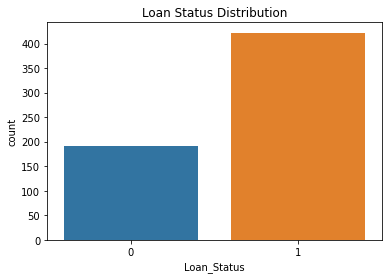

In [13]:
# 14. Visualizations
# Loan Status Distribution
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()


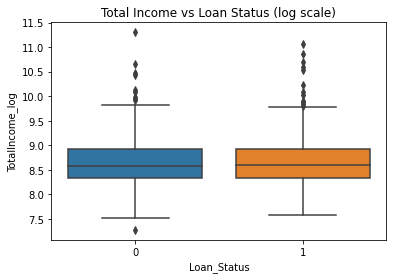

In [14]:
# Total Income vs Loan Status
sns.boxplot(x='Loan_Status', y='TotalIncome_log', data=df)
plt.title('Total Income vs Loan Status (log scale)')
plt.show()

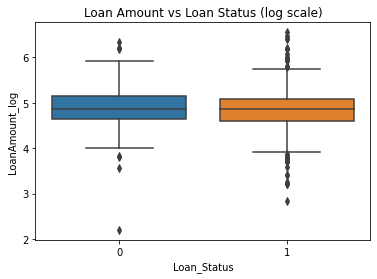

In [15]:
# Loan Amount vs Loan Status
sns.boxplot(x='Loan_Status', y='LoanAmount_log', data=df)
plt.title('Loan Amount vs Loan Status (log scale)')
plt.show()

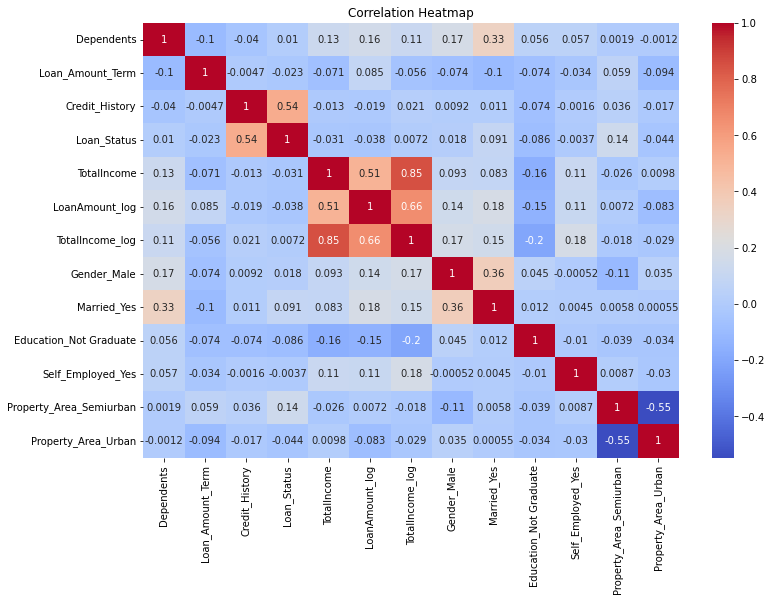

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

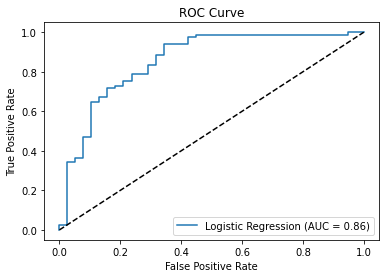

In [17]:
# 15. ROC Curve for Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_score(y_test, y_prob))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()